<a href="https://colab.research.google.com/github/winnercalvin/Fraud_Detection_Model/blob/main/%EC%82%AC%EA%B8%B0%EA%B1%B0%EB%9E%98%ED%83%90%EC%A7%80_livecoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 신용카드 사기 거래 탐지

##  학습 목표
1. 클래스 불균형 데이터 다루기
2. Confusion Matrix, Precision, Recall, F1-Score 이해
3. 표준화(Standardization) 적용
4. ROC Curve와 AUC 계산


In [1]:
!pip install -q torch scikit-learn matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
import torch
import torch.nn as nn
import torch.optim as optim

plt.rcParams['font.size'] = 15
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

In [4]:
# 불균형 데이터 생성 (sklearn.dataset 이용)
X, y = make_classification(
    n_samples=10000,
    n_features=30,
    n_informative=18,
    n_redundant=12,
    n_classes=2,
    weights=[0.95, 0.05], # 0 : 정상 / 1 : 사기
    flip_y = 0.01,
    random_state = 42
)

In [7]:
unique, counts = np.unique(y, return_counts=True)
print("정상거래(0): ", counts[0])
print("사기거래(1): ", counts[1])

정상거래(0):  9460
사기거래(1):  540


데이터 분할

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify =y, random_state=42)

In [10]:
X_train[:5]
X_test[:5]

array([[-1.08725053e+00, -9.78634053e+00, -3.32342393e+00,
         2.11398522e+00, -3.14877040e-01, -4.14037241e+00,
         2.22420703e+00,  6.04539088e-02,  3.08364944e+00,
         2.11890035e+00,  3.37566666e+00, -1.01160813e+00,
        -3.61681607e+00, -3.29418432e-01, -3.25764903e+00,
         5.39597730e+00,  1.60994890e+00,  1.03278937e+00,
        -9.06163626e+00, -1.61454358e+00, -1.13805984e+00,
        -3.00517564e+00,  4.52351568e-01, -7.29361199e-01,
         2.41289157e+00,  1.49567652e+00, -1.15749306e+00,
        -2.94871269e+00, -2.75517347e+00,  6.80508177e-02],
       [-8.66168441e-01, -4.62080694e+00,  1.51963363e-01,
         2.59417254e+00,  5.38120311e+00,  4.20271390e+00,
         1.44208587e+00, -7.93251584e+00,  1.30038358e+00,
         2.07786023e+00,  3.87748080e+00, -1.62938343e+00,
        -3.14391193e+00, -2.54129025e+00, -1.20276065e+00,
         1.80703779e+00, -2.07985442e+00, -4.94691316e+00,
        -2.65971529e+00, -2.39372109e+00,  3.73293803e-

데이터 표준화

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Pytorch 텐서 변환

In [20]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train).view(-1,1)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test).view(-1,1)

모델 정의

In [21]:
# 3층 구조
class FraudDetectionModel(nn.Module):
    def __init__(self, input_dim):
        super(FraudDetectionModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [22]:
# 모델 초기화
model = FraudDetectionModel(input_dim = 30)
print(model)

FraudDetectionModel(
  (fc1): Linear(in_features=30, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)


손실 함수 및 최적화 알고리즘 설정

In [23]:
pos_weight = torch.tensor([counts[0]/counts[1]]) # 클래스 불균형 시, 더 큰 가중치 부여
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=0.001)

모델 학습

In [24]:
num_epochs = 100
history = {'train_loss': [],'test_loss': [],'test_acc': [] }

for epoch in range(num_epochs):
  model.train()
  optimizer.zero_grad()

  outputs = model(X_train_tensor)

  loss = criterion(outputs, y_train_tensor)
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)
    test_pred = (test_outputs >= 0.0).float()
    test_acc = (test_pred == y_test_tensor).float().mean()

  history['train_loss'].append(loss.item())
  history['test_loss'].append(test_loss.item())
  history['test_acc'].append(test_acc.item())

  if (epoch + 1) % 20 == 0:
    print(f'Epoch [{epoch+1} / {num_epochs}] '
          f'Train_loss: {loss.item():.4f} | '
          f'Test_loss: {test_loss.item():.4f} | '
          f'Test_acc: {test_acc.item():.4f} | '
    )

Epoch [20 / 100] Train_loss: 0.9597 | Test_loss: 0.9151 | Test_acc: 0.8210 | 
Epoch [40 / 100] Train_loss: 0.6721 | Test_loss: 0.6275 | Test_acc: 0.8950 | 
Epoch [60 / 100] Train_loss: 0.5040 | Test_loss: 0.4704 | Test_acc: 0.9365 | 
Epoch [80 / 100] Train_loss: 0.3954 | Test_loss: 0.3957 | Test_acc: 0.9605 | 
Epoch [100 / 100] Train_loss: 0.3194 | Test_loss: 0.3698 | Test_acc: 0.9725 | 


학습 곡선 시각화

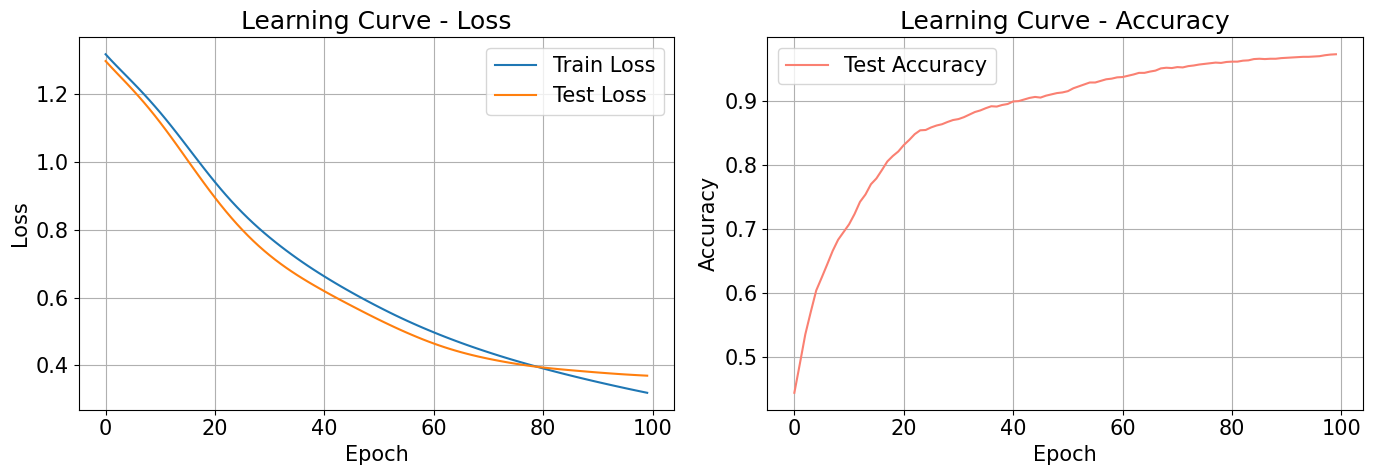

In [26]:
fig, axes = plt.subplots(1,2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['test_loss'], label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curve - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['test_acc'], label='Test Accuracy', color='salmon')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Learning Curve - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

상세 평가 지표 계산

In [27]:
model.eval()
with torch.no_grad():
  test_outputs = model(X_test_tensor)
  print(test_outputs)

tensor([[ 1.4416],
        [-1.3099],
        [-3.4959],
        ...,
        [ 4.5588],
        [-2.3767],
        [-2.2418]])


In [28]:
model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(test_outputs)
    print(test_probs)

tensor([[0.8087],
        [0.2125],
        [0.0294],
        ...,
        [0.9896],
        [0.0850],
        [0.0961]])


In [29]:
model.eval()
with torch.no_grad():
    test_pred = (test_outputs >=0.0).numpy().astype(int).flatten()
    print(test_pred)

[1 0 0 ... 1 0 0]


In [30]:
y_test_np = y_test.astype(int)
confusion_matrix(y_test_np, test_pred)

array([[1847,   45],
       [  10,   98]])

In [34]:
cm = confusion_matrix(y_test_np, test_pred)
print('='*50)
print('Confusion Matrix')
print('='*50)
print("                   Predicted")
print("                   0(정상)   1(사기)")
print(f"Actual  0(정상)    {cm[0,0]}      {cm[0,1]}")
print(f"        0(사기)    {cm[1,0]}        {cm[1,1]}")

Confusion Matrix
                   Predicted
                   0(정상)   1(사기)
Actual  0(정상)    1847      45
        0(사기)    10        98


In [36]:
# ravel() : 2차원 -> 1차원
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = precision_score(y_test_np, test_pred)
recall = recall_score(y_test_np, test_pred)
f1 = f1_score(y_test_np, test_pred)

print("="*50)
print("주요 평가지표")
print(f"Accuracy(정확도): {accuracy:.4f}")
print(f"Precision(정밀도): {precision:.4f}")
print(f"Recall(재현율/민감도): {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("="*50)

주요 평가지표
Accuracy(정확도): 0.9725
Precision(정밀도): 0.6853
Recall(재현율/민감도): 0.9074
F1-Score: 0.7809


ROC Curve & AUC

AUC: 0.9708


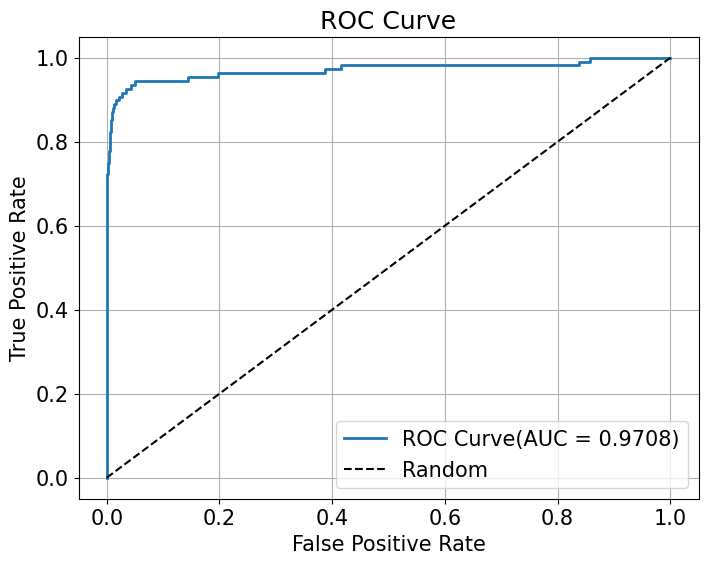

In [39]:
fpr, tpr, threholds = roc_curve(y_test_np, test_probs.numpy())

auc = roc_auc_score(y_test_np, test_probs.numpy())
print(f'AUC: {auc:.4f}')

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve(AUC = {auc:.4f})', linewidth=2)
plt.plot([0,1],[0,1],'k--', label="Random")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

혼동행렬 시각화

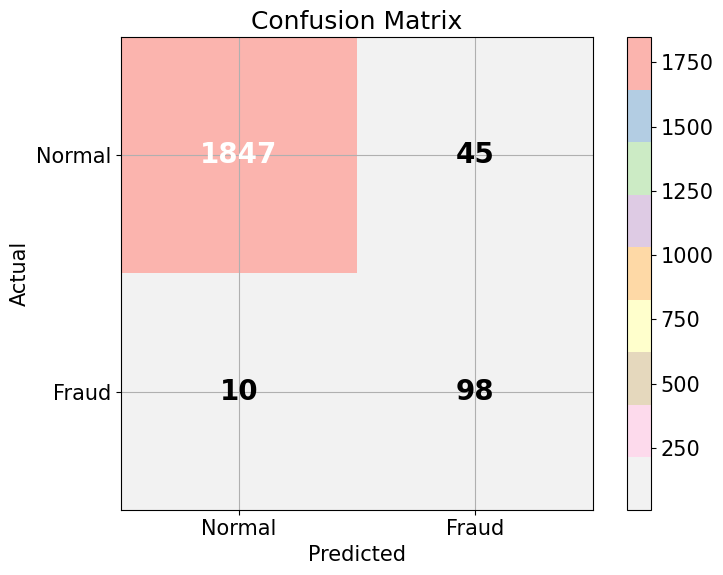

In [41]:
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap='Pastel1_r')

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'Fraud'])
ax.set_yticklabels(['Normal', 'Fraud'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title("Confusion Matrix")

for i in range(2):
  for j in range(2):
    ax.text(j, i, cm[i,j],
            ha = 'center',
            va ='center',
            color='white' if cm[i,j] >  cm.max()/2 else "black",
            fontsize = 20, fontweight='bold'
            )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()